# Credit Card Approval Prediction

Joining the application records with the monthly credit records to work out whether a client ends up past due on payments. The flow is: clean the data, deal with outliers, run hypothesis tests, explore the data, then train and compare three models (logistic regression, random forest, XGBoost).

In [4]:
# everything the notebook needs is imported once, here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from imblearn.over_sampling import RandomOverSampler
import xgboost as xgb

alpha = 0.05   # significance cutoff used later in the hypothesis tests

In [5]:
# put both csv files in a 'data' folder next to the notebook
application_path = 'data/application_record.csv'
credit_path = 'data/credit_record.csv'

# Loading the datasets
application = pd.read_csv(application_path)
credit = pd.read_csv(credit_path)

# the two files share the ID column, so we join on that
merged_data = pd.merge(application, credit, on='ID', how='inner')

# Display the first few rows and dimensions of the merged dataset
print("Merged Dataset Preview:")
print(merged_data.head())

print(f"Merged dataset dimensions: {merged_data.shape}")

Merged Dataset Preview:
        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008804           M            Y               Y             0   
2  5008804           M            Y               Y             0   
3  5008804           M            Y               Y             0   
4  5008804           M            Y               Y             0   

   AMT_INCOME_TOTAL NAME_INCOME_TYPE NAME_EDUCATION_TYPE NAME_FAMILY_STATUS  \
0          427500.0          Working    Higher education     Civil marriage   
1          427500.0          Working    Higher education     Civil marriage   
2          427500.0          Working    Higher education     Civil marriage   
3          427500.0          Working    Higher education     Civil marriage   
4          427500.0          Working    Higher education     Civil marriage   

  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE  \
0  Rent

## A first look at the data

Just checking the shape, the column types and what's missing before touching anything.

In [6]:
# Checking the structure and basic info of the merged dataset
print("Merged Dataset Info:")
print(merged_data.info())


Merged Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  object 
 2   FLAG_OWN_CAR         777715 non-null  object 
 3   FLAG_OWN_REALTY      777715 non-null  object 
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  object 
 7   NAME_EDUCATION_TYPE  777715 non-null  object 
 8   NAME_FAMILY_STATUS   777715 non-null  object 
 9   NAME_HOUSING_TYPE    777715 non-null  object 
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 

In [7]:
# Displaying summary statistics for numerical columns in the merged dataset
print("Merged Dataset Summary:")
print(merged_data.describe())


Merged Dataset Summary:
                 ID   CNT_CHILDREN  AMT_INCOME_TOTAL     DAYS_BIRTH  \
count  7.777150e+05  777715.000000      7.777150e+05  777715.000000   
mean   5.078743e+06       0.428082      1.885348e+05  -16124.937046   
std    4.180442e+04       0.745755      1.016225e+05    4104.304018   
min    5.008804e+06       0.000000      2.700000e+04  -25152.000000   
25%    5.044568e+06       0.000000      1.215000e+05  -19453.000000   
50%    5.069530e+06       0.000000      1.620000e+05  -15760.000000   
75%    5.115551e+06       1.000000      2.250000e+05  -12716.000000   
max    5.150487e+06      19.000000      1.575000e+06   -7489.000000   

       DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE     FLAG_PHONE  \
count  777715.000000    777715.0    777715.000000  777715.000000   
mean    57775.825016         1.0         0.231818       0.300965   
std    136471.735391         0.0         0.421993       0.458678   
min    -15713.000000         1.0         0.000000       0.000000

In [8]:
# Checking for missing values in the merged dataset
print("Missing values in the Merged Dataset:")
print(merged_data.isnull().sum())


Missing values in the Merged Dataset:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        240048
CNT_FAM_MEMBERS             0
MONTHS_BALANCE              0
STATUS                      0
dtype: int64


## Cleaning the data

Filling the missing occupation values, dropping duplicates, squashing STATUS down to a simple two-class target, and fixing the day/month columns that are stored as negatives.

In [9]:
# Fill missing categorical values with the mode
merged_data['OCCUPATION_TYPE'].fillna(merged_data['OCCUPATION_TYPE'].mode()[0], inplace=True)
# Verifying that missing values have been handled
print("Missing values after cleaning (Merged Dataset):")
print(merged_data.isnull().sum())

# Checking the dimensions after cleaning
print(f"Cleaned dataset dimensions: {merged_data.shape}")

/tmp/ipykernel_14220/4074167833.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['OCCUPATION_TYPE'].fillna(merged_data['OCCUPATION_TYPE'].mode()[0], inplace=True)


Missing values after cleaning (Merged Dataset):
ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
MONTHS_BALANCE         0
STATUS                 0
dtype: int64
Cleaned dataset dimensions: (777715, 20)


In [10]:
# Checking for duplicates in the dataset
print(f"Number of duplicate rows in the dataset: {merged_data.duplicated().sum()}")

# Removing duplicate rows
merged_data = merged_data.drop_duplicates()

# Verifying that duplicates have been removed
print(f"Number of duplicate rows after removal: {merged_data.duplicated().sum()}")
print(f"Dataset dimensions after duplicate removal: {merged_data.shape}")


Number of duplicate rows in the dataset: 0
Number of duplicate rows after removal: 0
Dataset dimensions after duplicate removal: (777715, 20)


In [11]:
# Checking for unique values in each column
# This helps identify categorical columns or columns that may need further processing.

for column in merged_data.columns:
    print(f"{column}: {merged_data[column].nunique()} unique values")


ID: 36457 unique values
CODE_GENDER: 2 unique values
FLAG_OWN_CAR: 2 unique values
FLAG_OWN_REALTY: 2 unique values
CNT_CHILDREN: 9 unique values
AMT_INCOME_TOTAL: 265 unique values
NAME_INCOME_TYPE: 5 unique values
NAME_EDUCATION_TYPE: 5 unique values
NAME_FAMILY_STATUS: 5 unique values
NAME_HOUSING_TYPE: 6 unique values
DAYS_BIRTH: 7183 unique values
DAYS_EMPLOYED: 3640 unique values
FLAG_MOBIL: 1 unique values
FLAG_WORK_PHONE: 2 unique values
FLAG_PHONE: 2 unique values
FLAG_EMAIL: 2 unique values
OCCUPATION_TYPE: 18 unique values
CNT_FAM_MEMBERS: 10 unique values
MONTHS_BALANCE: 61 unique values
STATUS: 8 unique values


In [12]:
# Checking the value counts of the 'STATUS' column
print("Value counts for the 'STATUS' column before mapping:")
print(merged_data['STATUS'].value_counts())

# Defining the mapping for the 'STATUS' column
status_mapping = {
    'C': 'no past dues',
    '0': 'no past dues',
    'X': 'no past dues',
    '1': 'past dues',
    '2': 'past dues',
    '3': 'past dues',
    '4': 'past dues',
    '5': 'past dues'
}

# Applying the mapping to the 'STATUS' column
merged_data['STATUS'] = merged_data['STATUS'].map(status_mapping)

# Checking the value counts after mapping
print("Value counts for the 'STATUS' column after mapping:")
print(merged_data['STATUS'].value_counts())


Value counts for the 'STATUS' column before mapping:
STATUS
C    329536
0    290654
X    145950
1      8747
5      1527
2       801
3       286
4       214
Name: count, dtype: int64
Value counts for the 'STATUS' column after mapping:
STATUS
no past dues    766140
past dues        11575
Name: count, dtype: int64


In [13]:
# Convert 'MONTHS_BALANCE' to positive by multiplying by -1
if 'MONTHS_BALANCE' in merged_data.columns:
    merged_data['MONTHS_BALANCE'] = merged_data['MONTHS_BALANCE'] * -1
    print("'MONTHS_BALANCE' column values converted to positive.")

# Replace positive values in 'DAYS_EMPLOYED' with 0
col_name = 'DAYS_EMPLOYED'
if col_name in merged_data.columns:
    merged_data[col_name] = merged_data[col_name].apply(lambda x: 0 if x > 0 else x)
    print(f"Positive values in '{col_name}' replaced with 0.")

# Convert 'DAYS_EMPLOYED' and 'DAYS_BIRTH' to positive by multiplying by -1
for col in ['DAYS_EMPLOYED', 'DAYS_BIRTH']:
    if col in merged_data.columns:
        merged_data[col] = merged_data[col] * -1
        print(f"'{col}' column values converted to positive.")

# Display the first few rows of the transformed dataset
print("Transformed Dataset Preview:")
print(merged_data.head())


'MONTHS_BALANCE' column values converted to positive.
Positive values in 'DAYS_EMPLOYED' replaced with 0.
'DAYS_EMPLOYED' column values converted to positive.
'DAYS_BIRTH' column values converted to positive.
Transformed Dataset Preview:
        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008804           M            Y               Y             0   
2  5008804           M            Y               Y             0   
3  5008804           M            Y               Y             0   
4  5008804           M            Y               Y             0   

   AMT_INCOME_TOTAL NAME_INCOME_TYPE NAME_EDUCATION_TYPE NAME_FAMILY_STATUS  \
0          427500.0          Working    Higher education     Civil marriage   
1          427500.0          Working    Higher education     Civil marriage   
2          427500.0          Working    Higher education     Civil marriage   
3          427500.0          Wo

## Spotting and handling outliers

Boxplots first to see how bad it is, cap the extreme values with the usual IQR rule, then plot again to check it actually worked.

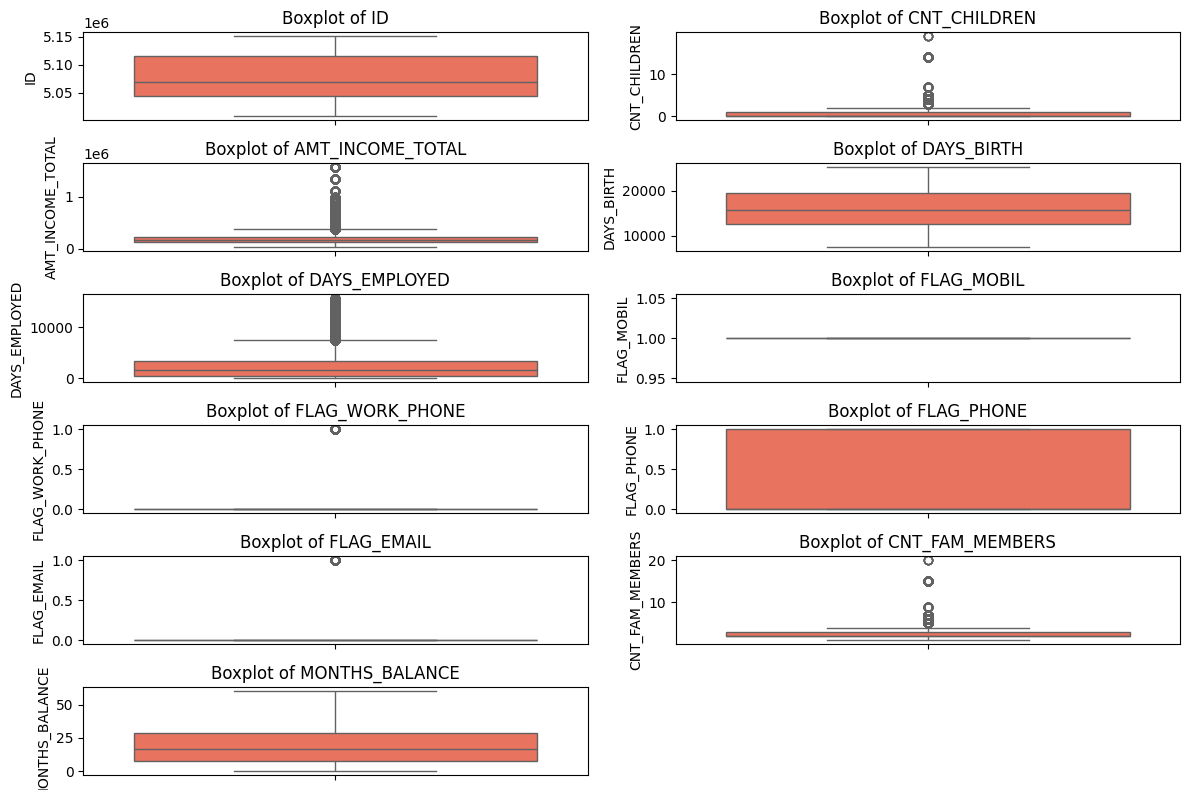

In [14]:
# Select numeric columns
numeric_columns = merged_data.select_dtypes(include=['number']).columns

# Create boxplots for all numeric columns
plt.figure(figsize=(12, 8))

# Loop through each numeric column and create a boxplot
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 2 + 1, 2, i)  # Adjusting subplot layout
    sns.boxplot(data=merged_data, y=col, color='tomato')
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.ylabel(col, fontsize=10)

plt.tight_layout()  # Adjust layout to fit all plots
plt.show()


In [15]:
import numpy as np

# Function to handle outliers using the IQR method
def handle_outliers(x, coef=1.5):
    # Calculate Q1, Q3, and IQR
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lower_bound = q1 - coef * iqr
    upper_bound = q3 + coef * iqr

    # Replace values below lower bound with lower bound and above upper bound with upper bound
    x = np.where(x < lower_bound, lower_bound, x)
    x = np.where(x > upper_bound, upper_bound, x)

    return x

# Handle outliers in the 'AMT_INCOME_TOTAL' column
if 'AMT_INCOME_TOTAL' in merged_data.columns:
    merged_data['AMT_INCOME_TOTAL'] = handle_outliers(merged_data['AMT_INCOME_TOTAL'])

# Handle outliers in the 'CNT_CHILDREN' column
if 'CNT_CHILDREN' in merged_data.columns:
    merged_data['CNT_CHILDREN'] = handle_outliers(merged_data['CNT_CHILDREN'])

# Handle outliers in the 'CNT_FAM_MEMBERS' column
if 'CNT_FAM_MEMBERS' in merged_data.columns:
    merged_data['CNT_FAM_MEMBERS'] = handle_outliers(merged_data['CNT_FAM_MEMBERS'])

if 'CNT_FAM_MEMBERS' in merged_data.columns:
    merged_data['DAYS_EMPLOYED'] = handle_outliers(merged_data['DAYS_EMPLOYED'])
# Verifying the outlier handling
print("Outliers handled successfully.")
print(merged_data[['AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']].describe())



Outliers handled successfully.
       AMT_INCOME_TOTAL   CNT_CHILDREN  CNT_FAM_MEMBERS
count     777715.000000  777715.000000    777715.000000
mean      183381.285621       0.416648         2.197983
std        81920.449447       0.690885         0.863799
min        27000.000000       0.000000         1.000000
25%       121500.000000       0.000000         2.000000
50%       162000.000000       0.000000         2.000000
75%       225000.000000       1.000000         3.000000
max       380250.000000       2.500000         4.500000


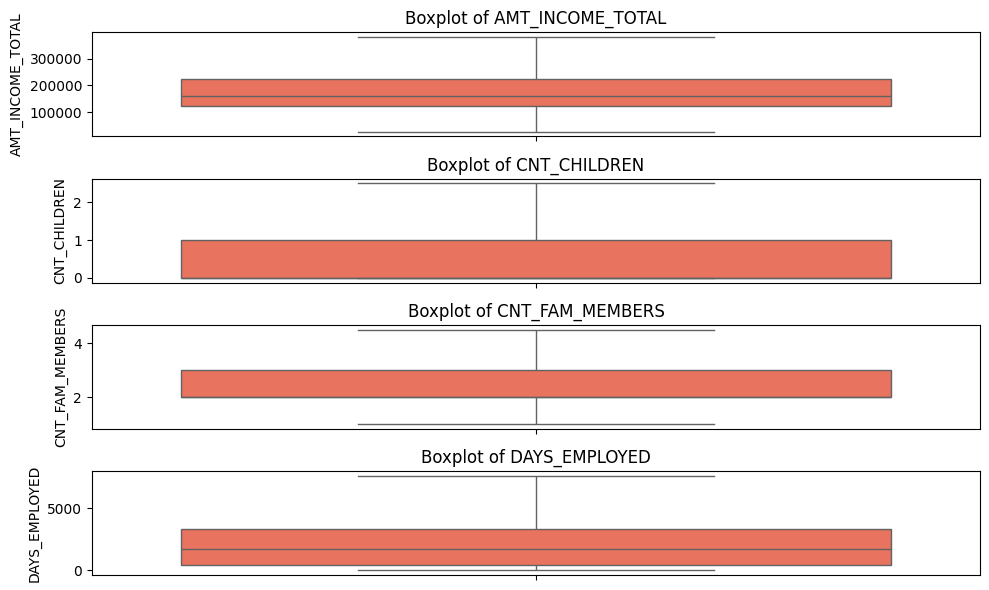

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
# ensuring outliers are removed
# Define the specific columns you want boxplots for
columns_to_plot = ['AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED']  # Example columns

# Create boxplots for the specified columns
plt.figure(figsize=(10, 6))

# Loop through each specified column and create a boxplot
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(len(columns_to_plot), 1, i)  # Adjusting subplot layout
    sns.boxplot(data=merged_data, y=col, color='tomato')
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.ylabel(col, fontsize=10)

plt.tight_layout()  # Adjust layout to fit all plots
plt.show()


## Hypothesis testing

Before building the models I wanted to actually test a few things about the data instead of just guessing from the plots. Doing this here on purpose, while the categorical columns are still text and STATUS is still labelled, so the groups make sense.

Quick reminder on how I'm reading these: if p < 0.05 we reject H0.

**Income vs gender**

H0: men and women earn about the same on average

H1: there's a real gap

Going with Welch's t-test (not assuming the two groups have equal variance).

In [17]:
male_income = merged_data.loc[merged_data['CODE_GENDER'] == 'M', 'AMT_INCOME_TOTAL']
female_income = merged_data.loc[merged_data['CODE_GENDER'] == 'F', 'AMT_INCOME_TOTAL']

t_stat, p_val = stats.ttest_ind(male_income, female_income, equal_var=False)
print(f"t = {t_stat:.3f}, p = {p_val:.4g}")
print("reject H0 -> income differs by gender" if p_val < alpha else "can't reject H0")

t = 205.384, p = 0
reject H0 -> income differs by gender


**Income for past-due vs non past-due clients**

H0: income is the same whether or not someone falls behind

H1: it isn't

In [18]:
income_past = merged_data.loc[merged_data['STATUS'] == 'past dues', 'AMT_INCOME_TOTAL']
income_ok   = merged_data.loc[merged_data['STATUS'] == 'no past dues', 'AMT_INCOME_TOTAL']

t_stat, p_val = stats.ttest_ind(income_past, income_ok, equal_var=False)
print(f"t = {t_stat:.3f}, p = {p_val:.4g}")
print("reject H0" if p_val < alpha else "can't reject H0")

t = 1.805, p = 0.07117
can't reject H0


**Months balance for past-due vs non past-due**

Same question, but looking at how far back the credit history goes.

In [19]:
mb_past = merged_data.loc[merged_data['STATUS'] == 'past dues', 'MONTHS_BALANCE']
mb_ok   = merged_data.loc[merged_data['STATUS'] == 'no past dues', 'MONTHS_BALANCE']

t_stat, p_val = stats.ttest_ind(mb_past, mb_ok, equal_var=False)
print(f"t = {t_stat:.3f}, p = {p_val:.4g}")
print("reject H0" if p_val < alpha else "can't reject H0")

t = 12.641, p = 2.154e-36
reject H0


**Income across education levels (one-way ANOVA)**

More than two groups here so a t-test doesn't work, ANOVA instead.

H0: every education level has the same average income

H1: at least one is different

In [20]:
edu_groups = [g['AMT_INCOME_TOTAL'].values for _, g in merged_data.groupby('NAME_EDUCATION_TYPE')]
f_stat, p_val = stats.f_oneway(*edu_groups)
print(f"F = {f_stat:.3f}, p = {p_val:.4g}")
print("reject H0 -> income depends on education" if p_val < alpha else "can't reject H0")

F = 12164.257, p = 0
reject H0 -> income depends on education


**Income across housing type**

Running Tukey after the ANOVA this time so we can see which specific housing types differ from each other, not only that some do.

In [21]:
house_groups = [g['AMT_INCOME_TOTAL'].values for _, g in merged_data.groupby('NAME_HOUSING_TYPE')]
f_stat, p_val = stats.f_oneway(*house_groups)
print(f"F = {f_stat:.3f}, p = {p_val:.4g}")

tukey = pairwise_tukeyhsd(merged_data['AMT_INCOME_TOTAL'], merged_data['NAME_HOUSING_TYPE'], alpha=alpha)
print(tukey)

F = 382.303, p = 0
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
       group1              group2         meandiff  p-adj     lower       upper    reject
-----------------------------------------------------------------------------------------
    Co-op apartment   House / apartment -17501.5651    0.0 -21368.3714 -13634.7589   True
    Co-op apartment Municipal apartment -28570.6585    0.0 -32703.5256 -24437.7915   True
    Co-op apartment    Office apartment   7600.5012 0.0002    2648.706  12552.2963   True
    Co-op apartment    Rented apartment    2321.782 0.6742  -2134.9836   6778.5477  False
    Co-op apartment        With parents  -22306.418    0.0 -26355.5602 -18257.2758   True
  House / apartment Municipal apartment -11069.0934    0.0 -12580.5044  -9557.6824   True
  House / apartment    Office apartment  25102.0663    0.0  21983.7256   28220.407   True
  House / apartment    Rented apartment  19823.3472    0.0   17572.451  22074.243

**Income across occupation type**

Same approach, by job.

In [22]:
occ_groups = [g['AMT_INCOME_TOTAL'].values for _, g in merged_data.groupby('OCCUPATION_TYPE')]
f_stat, p_val = stats.f_oneway(*occ_groups)
print(f"F = {f_stat:.3f}, p = {p_val:.4g}")

tukey = pairwise_tukeyhsd(merged_data['AMT_INCOME_TOTAL'], merged_data['OCCUPATION_TYPE'], alpha=alpha)
print(tukey)

F = 5116.671, p = 0
                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
        group1                group2          meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------------------------------------
          Accountants        Cleaning staff -51855.1871    0.0  -54878.9812 -48831.3929   True
          Accountants         Cooking staff -57196.2124    0.0  -60055.3049   -54337.12   True
          Accountants            Core staff -14057.8858    0.0  -15968.7166 -12147.0549   True
          Accountants               Drivers   4913.6221    0.0    2854.6379   6972.6063   True
          Accountants              HR staff  -21286.396    0.0  -28088.6989 -14484.0931   True
          Accountants High skill tech staff  -7522.3911    0.0   -9760.9378  -5283.8444   True
          Accountants              IT staff  16564.3425    0.0     8922.677  24206.0079   True
          Accountants         

**Does payment behaviour depend on the job?**

Coding STATUS as 0/1 just for this one so ANOVA has a number to work with.

H0: the past-due rate is the same across occupations

H1: some jobs are riskier than others

In [23]:
status_num = (merged_data['STATUS'] == 'past dues').astype(int)
occ_status_groups = [status_num[merged_data['OCCUPATION_TYPE'] == occ].values
                     for occ in merged_data['OCCUPATION_TYPE'].unique()]
f_stat, p_val = stats.f_oneway(*occ_status_groups)
print(f"F = {f_stat:.3f}, p = {p_val:.4g}")
print("reject H0 -> default rate varies by job" if p_val < alpha else "can't reject H0")

F = 22.458, p = 1.237e-70
reject H0 -> default rate varies by job


**Two-way ANOVA: education and occupation together**

Checking education, occupation, and the interaction between them all at once. The interaction row tells us if the effect of education on income changes depending on the job.

In [24]:
model = ols('AMT_INCOME_TOTAL ~ C(NAME_EDUCATION_TYPE) * C(OCCUPATION_TYPE)', data=merged_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                                 sum_sq        df  \
C(NAME_EDUCATION_TYPE)                     3.988659e+14       4.0   
C(OCCUPATION_TYPE)                         1.052292e+08      17.0   
C(NAME_EDUCATION_TYPE):C(OCCUPATION_TYPE)  1.372522e+14      68.0   
Residual                                   4.506772e+15  777648.0   

                                                      F  PR(>F)  
C(NAME_EDUCATION_TYPE)                     17206.177703     0.0  
C(OCCUPATION_TYPE)                             0.001068     1.0  
C(NAME_EDUCATION_TYPE):C(OCCUPATION_TYPE)    348.279555     0.0  
Residual                                            NaN     NaN  


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 13
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 68, but rank is 60
  warnings.warn('covariance of constraints does not have full '


**Income vs car ownership (non-parametric)**

Income is heavily skewed so instead of forcing another t-test I'm using Mann-Whitney (this is the same call the R version made with wilcox.test).

H0: car owners and non-owners have the same income distribution

H1: they don't

In [25]:
car_yes = merged_data.loc[merged_data['FLAG_OWN_CAR'] == 'Y', 'AMT_INCOME_TOTAL']
car_no  = merged_data.loc[merged_data['FLAG_OWN_CAR'] == 'N', 'AMT_INCOME_TOTAL']

u_stat, p_val = stats.mannwhitneyu(car_yes, car_no, alternative='two-sided')
print(f"U = {u_stat:.1f}, p = {p_val:.4g}")
print("reject H0" if p_val < alpha else "can't reject H0")

U = 92381499892.5, p = 0
reject H0


## Exploring the data

Now that it's clean, looking at the distributions and how the different groups relate to income and to whether someone falls behind on payments.

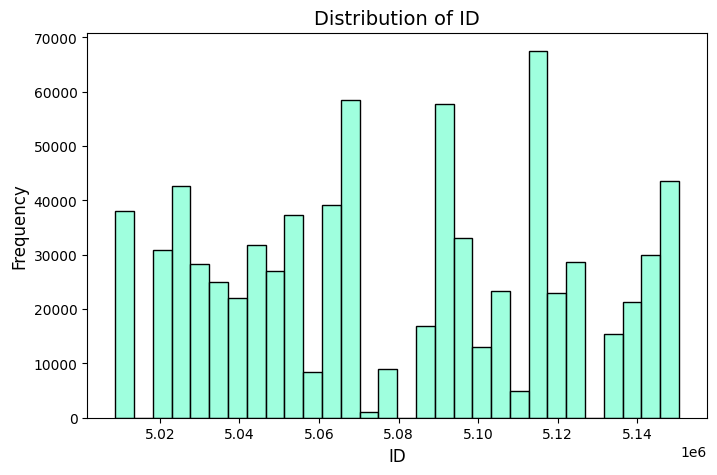

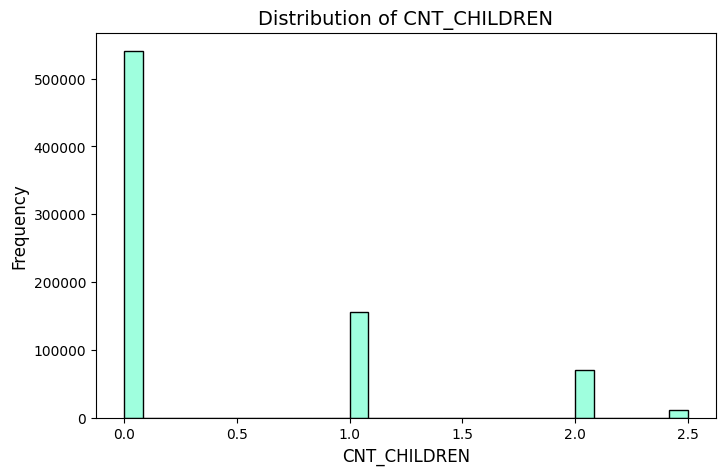

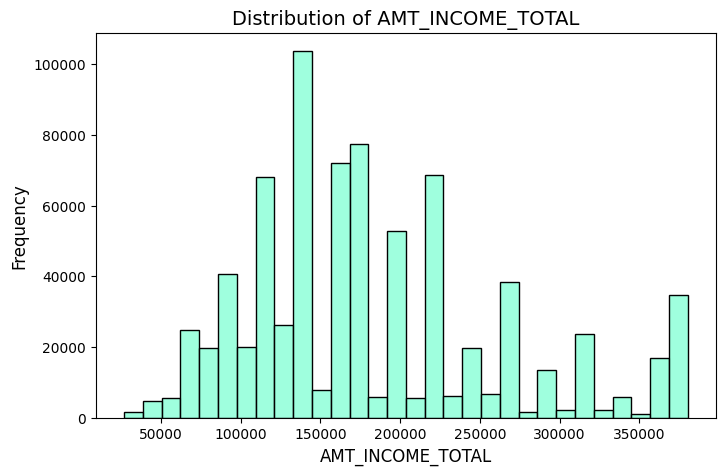

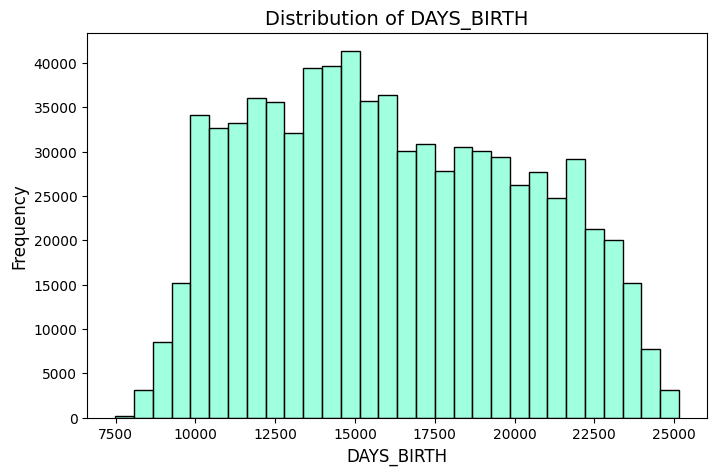

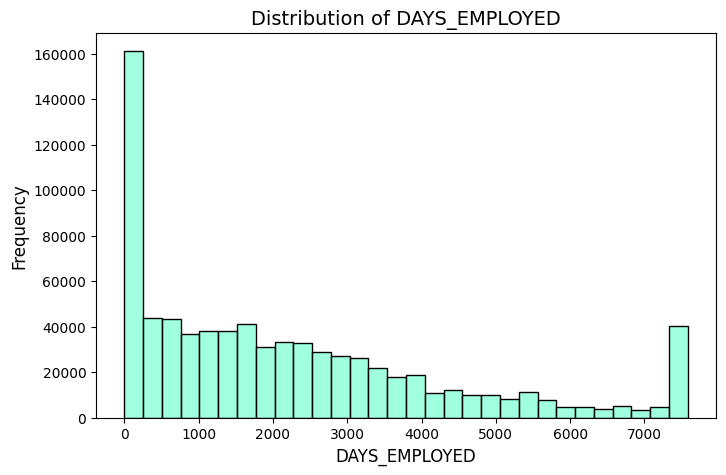

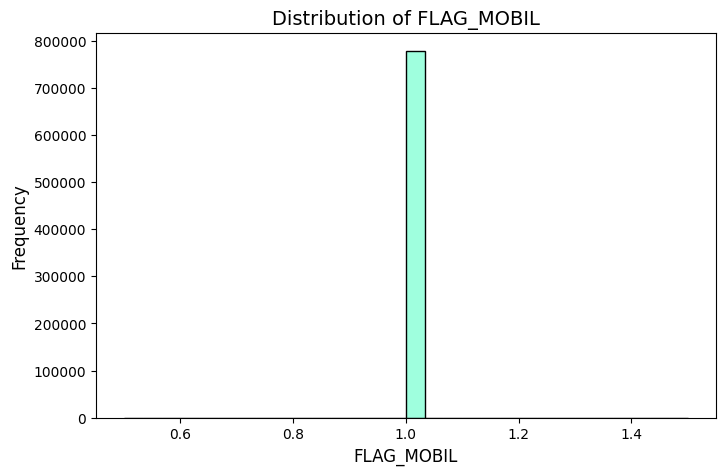

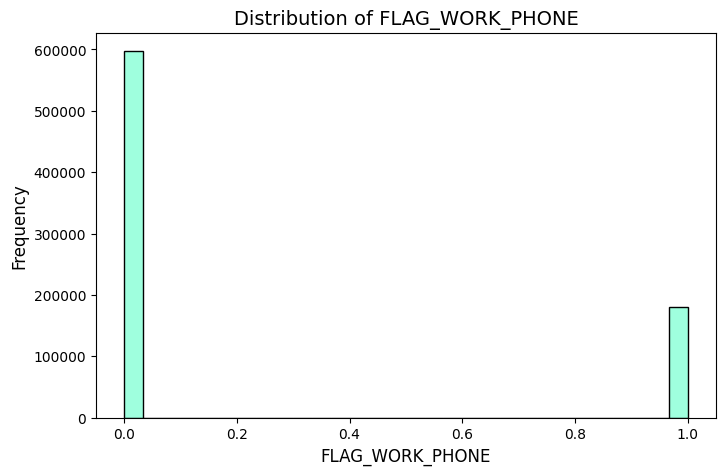

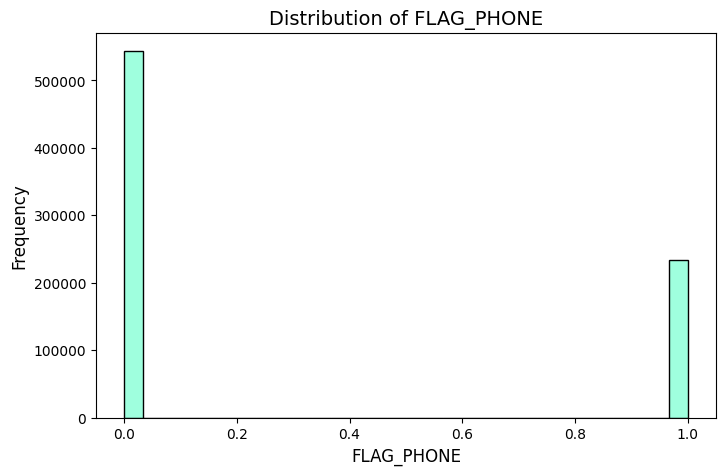

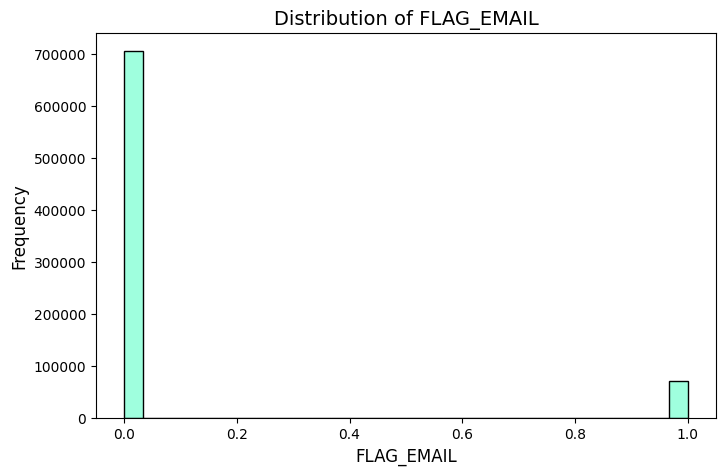

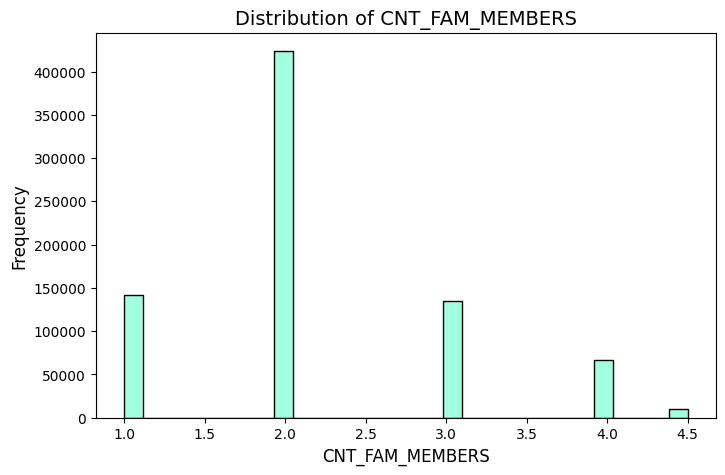

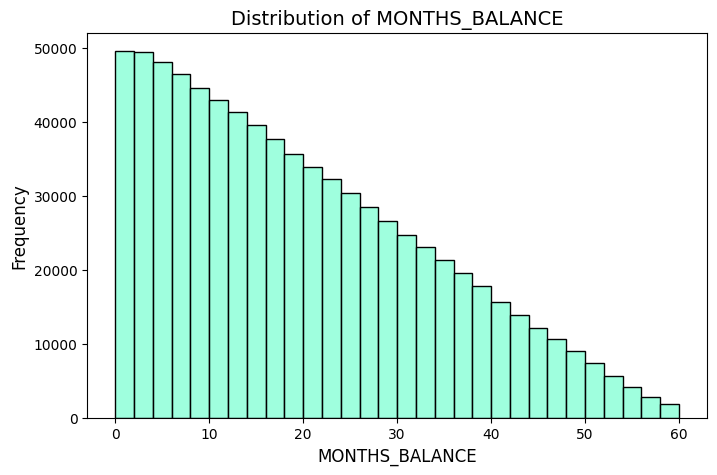

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
# getting a sense of the data distribution/visualization
# Select numeric columns
numeric_columns = merged_data.select_dtypes(include=['number']).columns

# Create histograms for all numeric columns
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=merged_data, x=col, color='aquamarine', edgecolor='black', bins=30)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()


In [27]:
# copy the "STATUS" column before modifying it, to use later.
status_col = merged_data['STATUS']
# Convert 'STATUS' to numeric using pandas' factorization
merged_data['STATUS'] = pd.factorize(merged_data['STATUS'])[0]


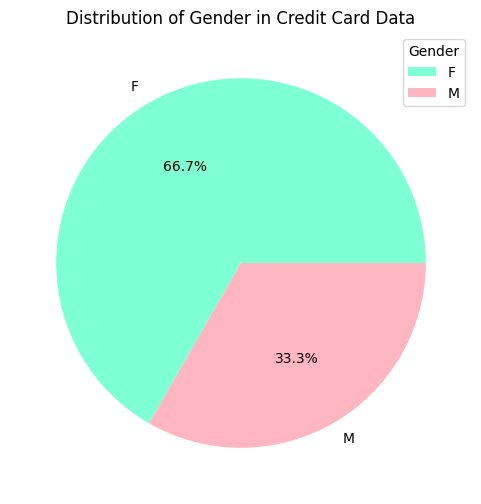

In [28]:
import matplotlib.pyplot as plt

# Calculate gender counts and percentages
gender_counts = merged_data['CODE_GENDER'].value_counts()
gender_percentages = (gender_counts / gender_counts.sum() * 100).round(1)

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_percentages.index, autopct='%1.1f%%', colors=['aquamarine', 'lightpink'])
plt.title('Distribution of Gender in Credit Card Data')
plt.legend(title="Gender")
plt.show()


/tmp/ipykernel_14220/2511732976.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, count + 5, f"{count}\n({percentages[i]}%)", ha='center')


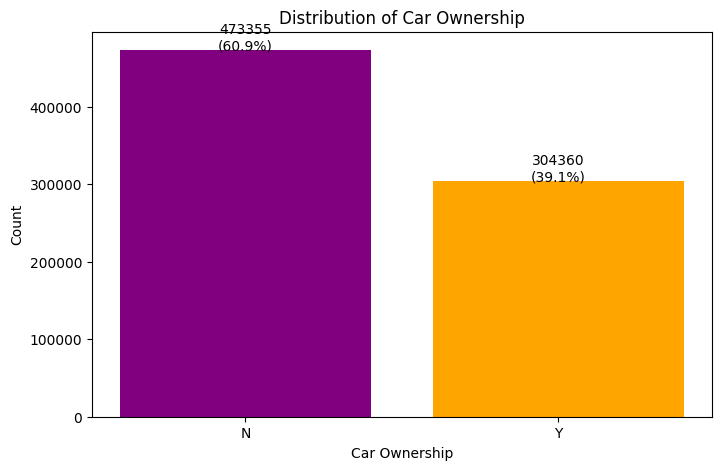

In [29]:
# Calculate car ownership counts and percentages
car_ownership_counts = merged_data['FLAG_OWN_CAR'].value_counts()
percentages = (car_ownership_counts / car_ownership_counts.sum() * 100).round(1)

# Create a bar plot
plt.figure(figsize=(8, 5))
bar_positions = range(len(car_ownership_counts))
plt.bar(bar_positions, car_ownership_counts, color=['purple', 'orange'])
plt.xticks(bar_positions, car_ownership_counts.index)
plt.title('Distribution of Car Ownership')
plt.xlabel('Car Ownership')
plt.ylabel('Count')

# Add labels
for i, count in enumerate(car_ownership_counts):
    plt.text(i, count + 5, f"{count}\n({percentages[i]}%)", ha='center')

plt.show()


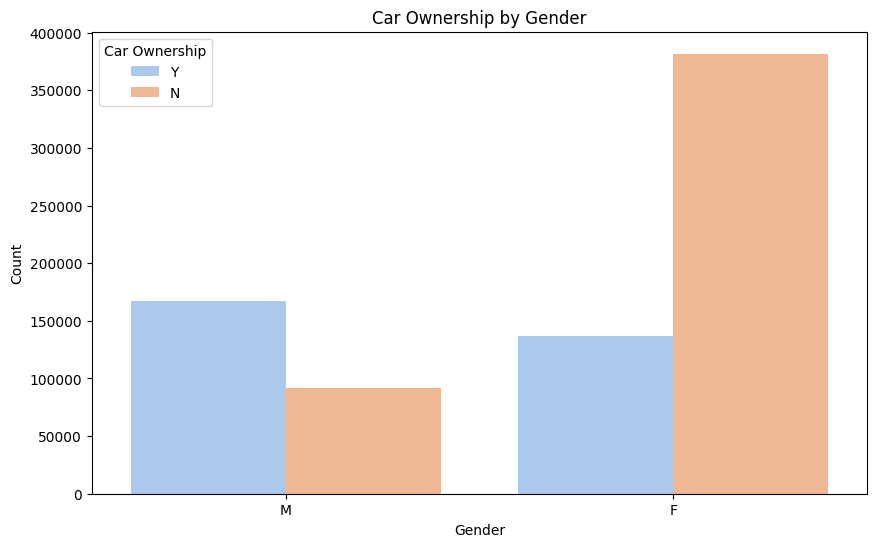

In [30]:
import seaborn as sns

# Create a bar plot for car ownership by gender
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_data, x='CODE_GENDER', hue='FLAG_OWN_CAR', palette='pastel')
plt.title('Car Ownership by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Car Ownership')
plt.show()


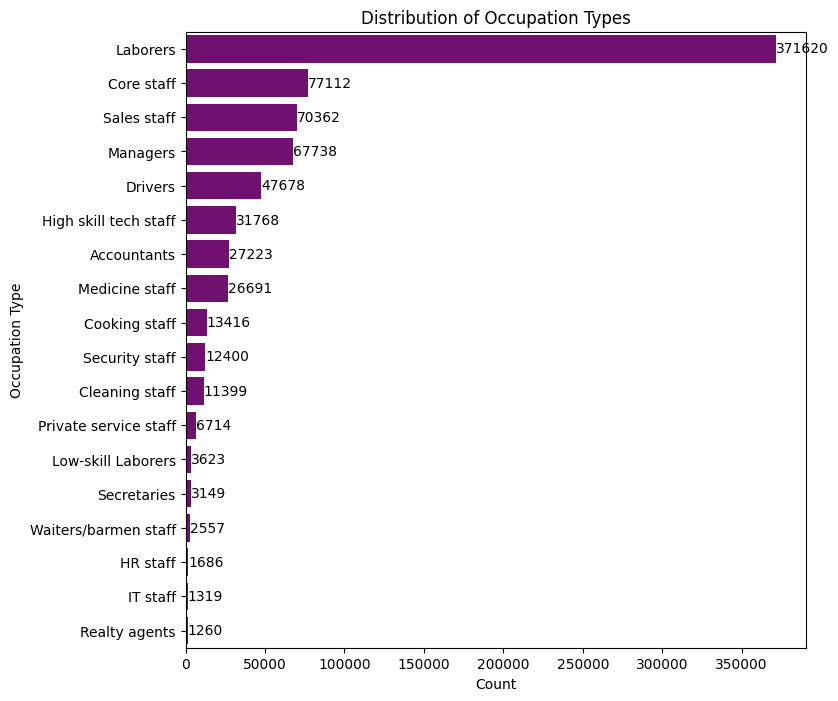

In [31]:
# Count occupation types and sort
occupation_counts = merged_data['OCCUPATION_TYPE'].value_counts().sort_values(ascending=False)

# Create a horizontal bar plot
plt.figure(figsize=(8, 8))
sns.barplot(x=occupation_counts.values, y=occupation_counts.index, color='purple')
plt.title('Distribution of Occupation Types')
plt.xlabel('Count')
plt.ylabel('Occupation Type')

# Add count labels
for i, count in enumerate(occupation_counts):
    plt.text(count, i, f'{count}', va='center')

plt.show()


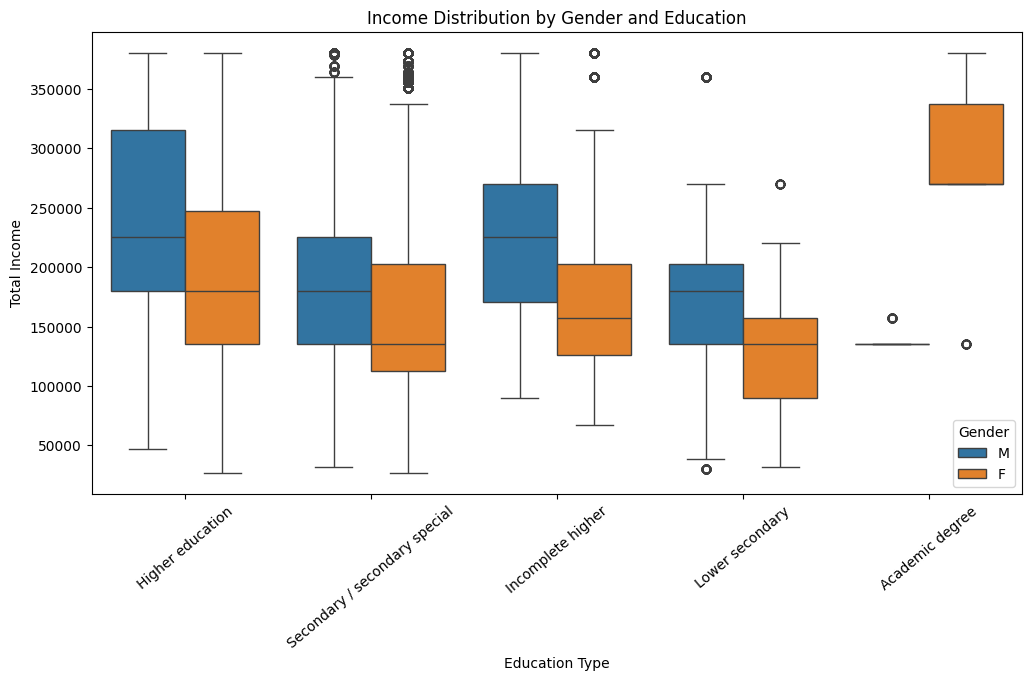

In [32]:
# Create boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_data, x='NAME_EDUCATION_TYPE', y='AMT_INCOME_TOTAL', hue='CODE_GENDER')
plt.title('Income Distribution by Gender and Education')
plt.xlabel('Education Type')
plt.ylabel('Total Income')
plt.xticks(rotation=40)
plt.legend(title='Gender')
plt.show()


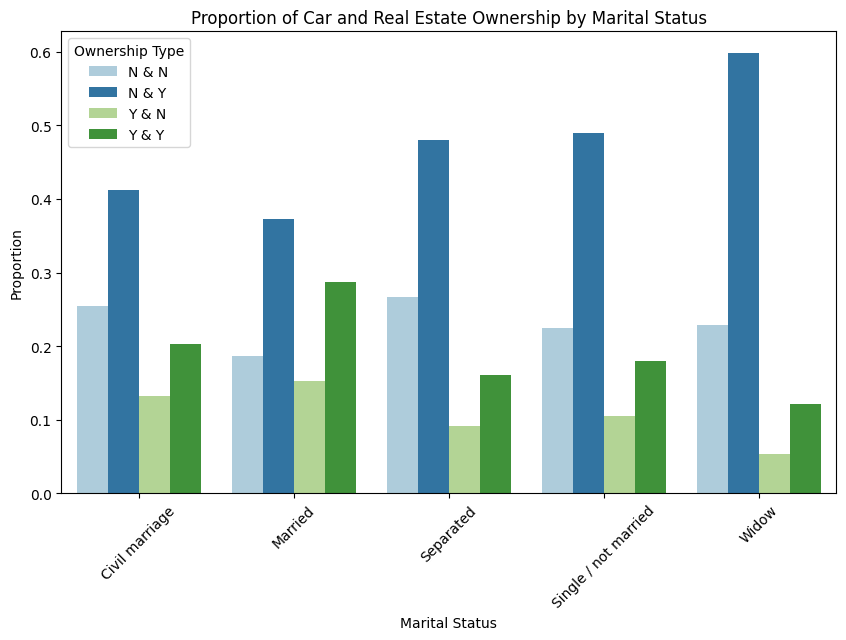

In [33]:
# Create a new column combining car and real estate ownership statuses
merged_data['Ownership_Status'] = merged_data['FLAG_OWN_CAR'] + ' & ' + merged_data['FLAG_OWN_REALTY']

# Calculate proportions
ownership_data = merged_data.groupby(['NAME_FAMILY_STATUS', 'Ownership_Status']).size().reset_index(name='Count')
ownership_data['Proportion'] = ownership_data.groupby('NAME_FAMILY_STATUS')['Count'].transform(lambda x: x / x.sum())

# Create a stacked bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=ownership_data, x='NAME_FAMILY_STATUS', y='Proportion', hue='Ownership_Status', palette='Paired')
plt.title('Proportion of Car and Real Estate Ownership by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Proportion')
plt.legend(title='Ownership Type')
plt.xticks(rotation=45)
plt.show()


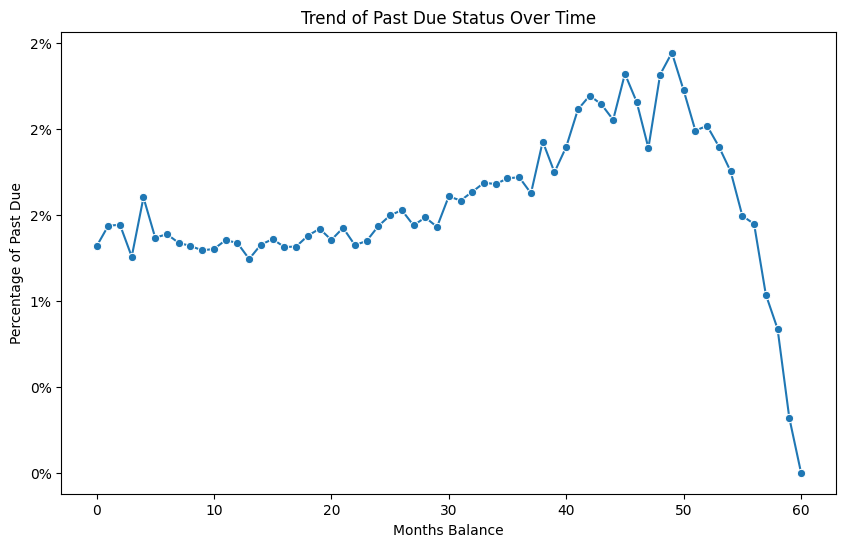

In [34]:
# Calculate proportion of past dues for each month
trend_data = merged_data.groupby('MONTHS_BALANCE')['STATUS'].apply(lambda x: (x == 1).mean()).reset_index(name='Proportion_Past_Due')

# Create line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_data, x='MONTHS_BALANCE', y='Proportion_Past_Due', marker='o')
plt.title('Trend of Past Due Status Over Time')
plt.xlabel('Months Balance')
plt.ylabel('Percentage of Past Due')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.show()


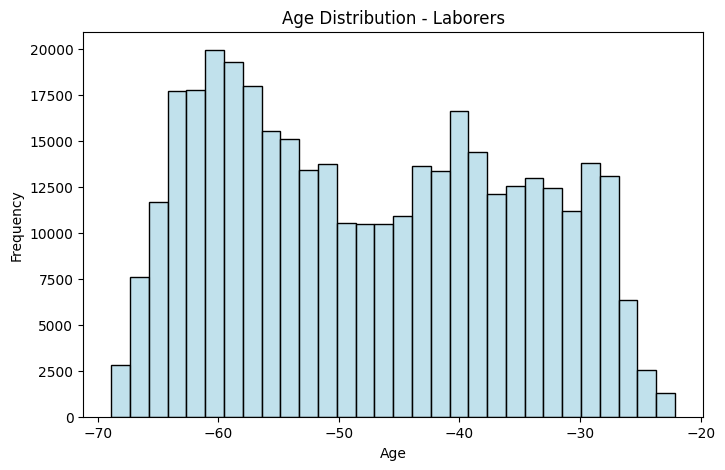

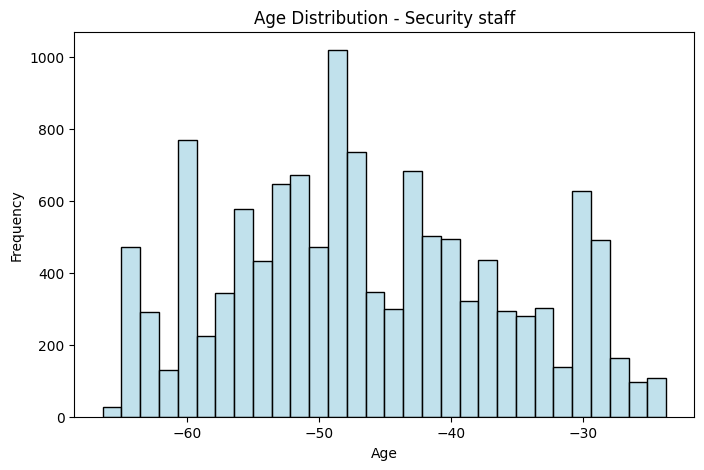

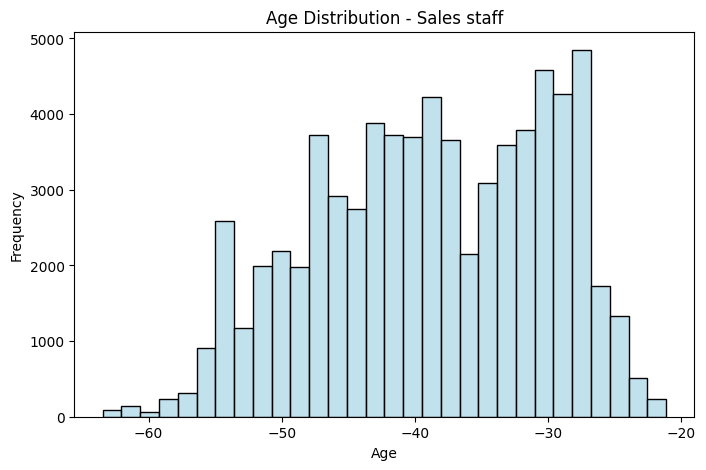

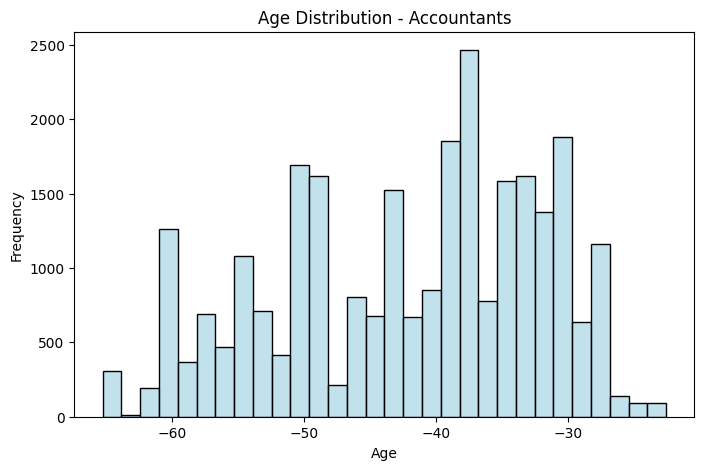

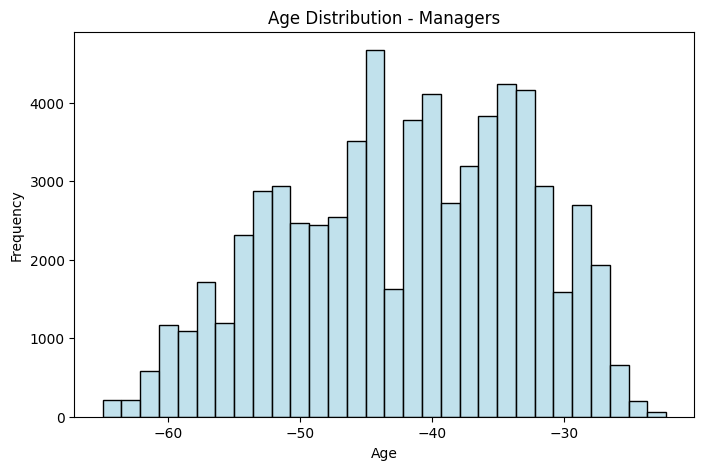

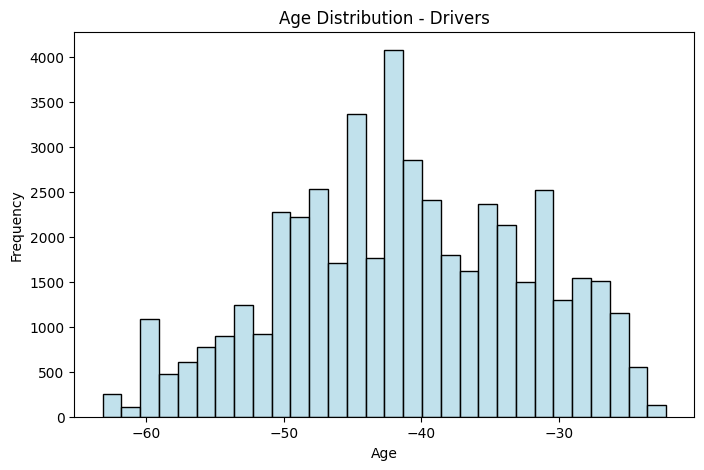

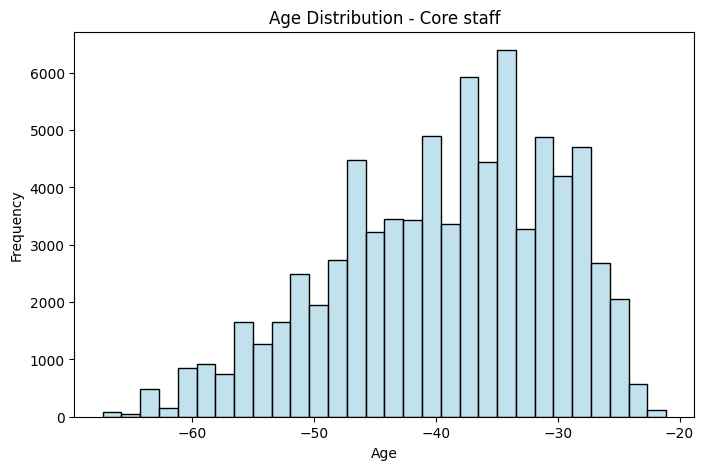

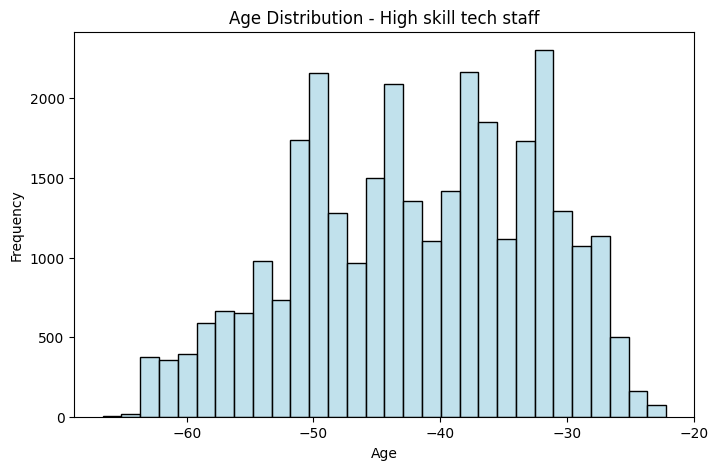

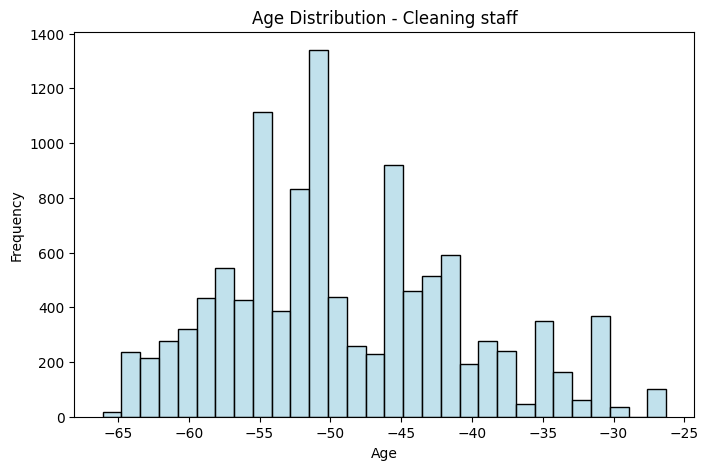

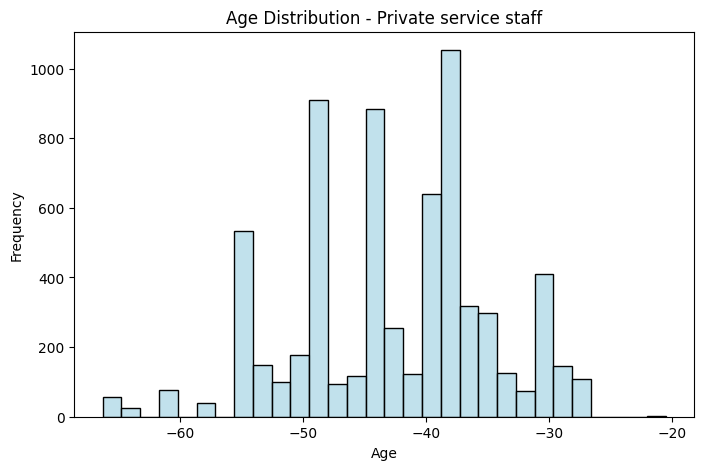

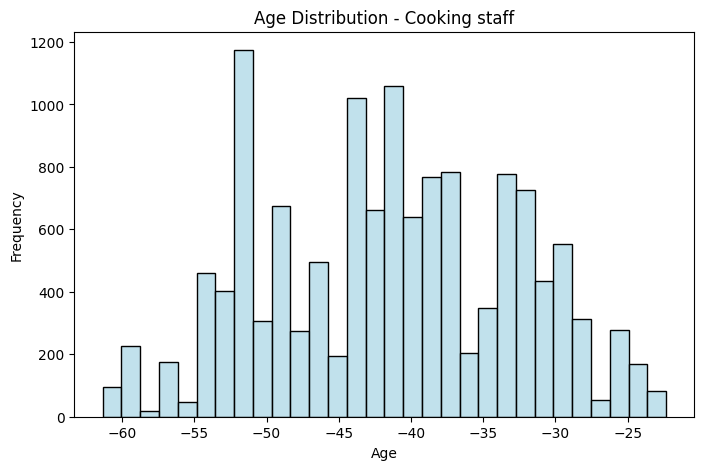

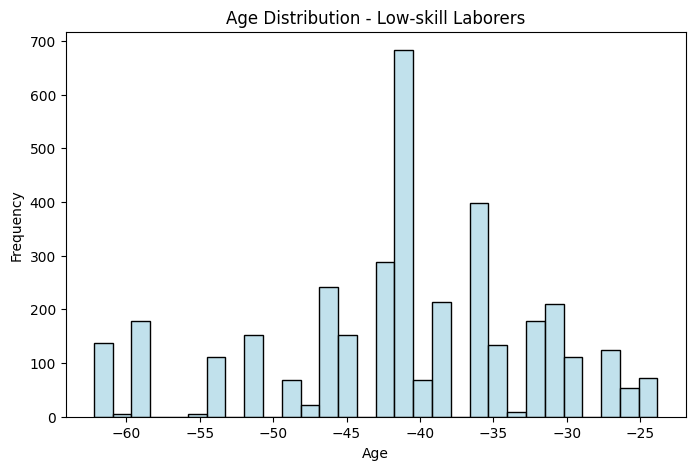

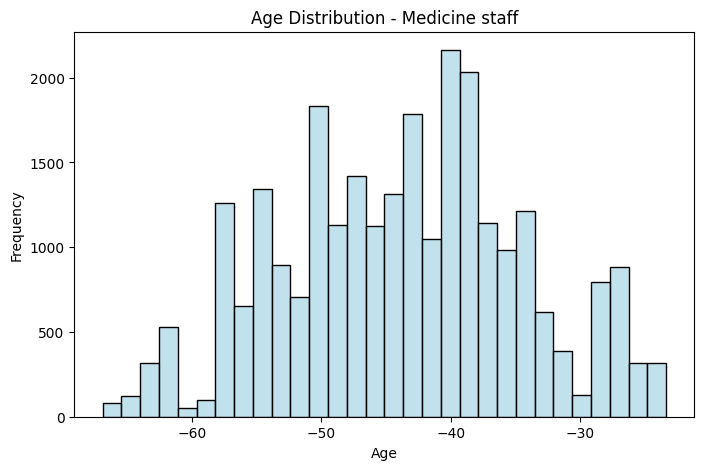

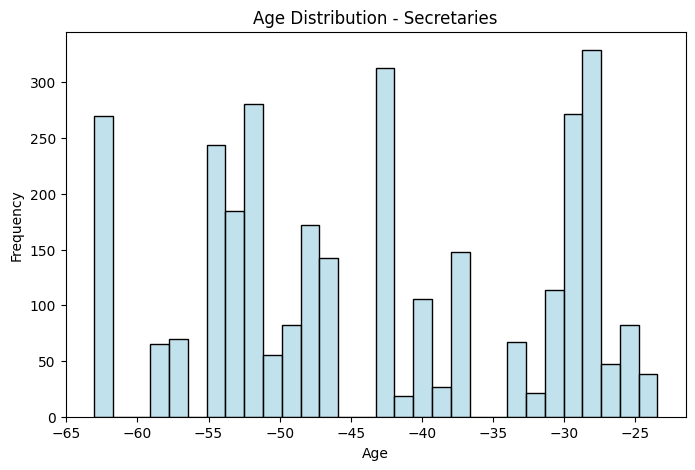

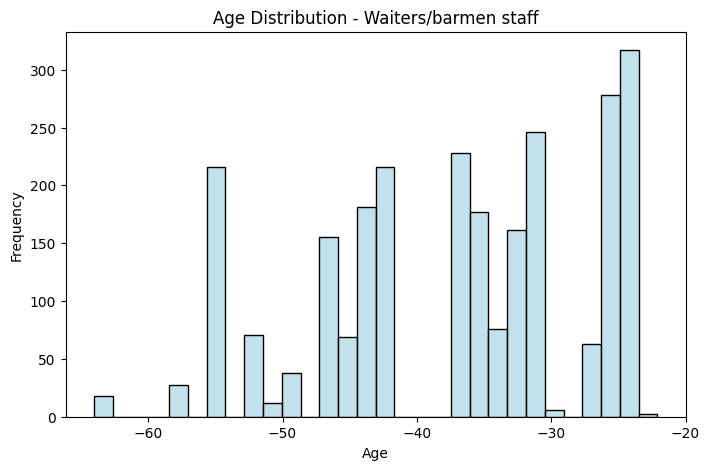

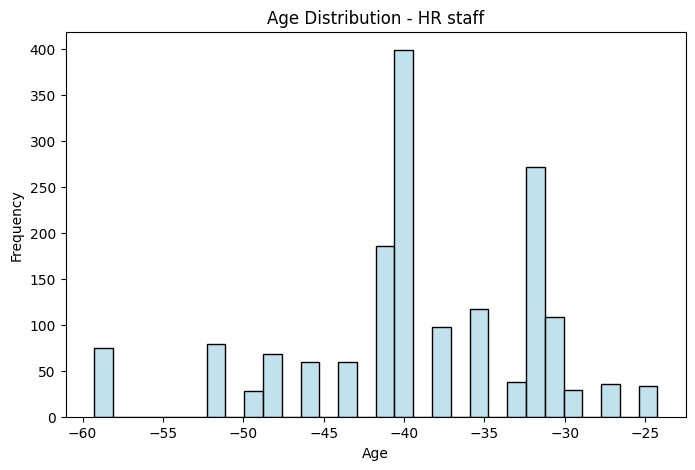

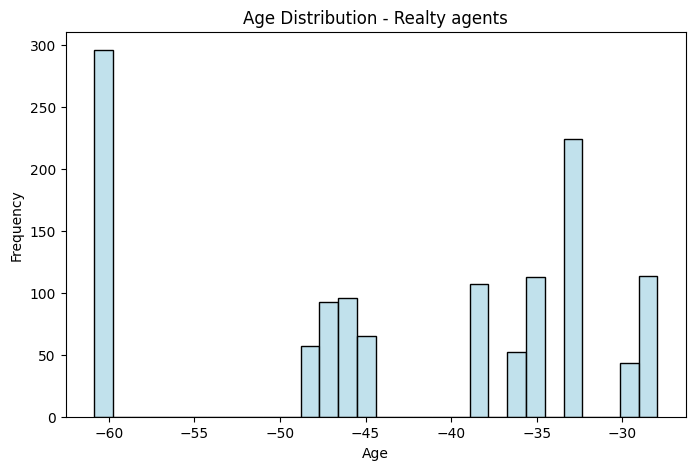

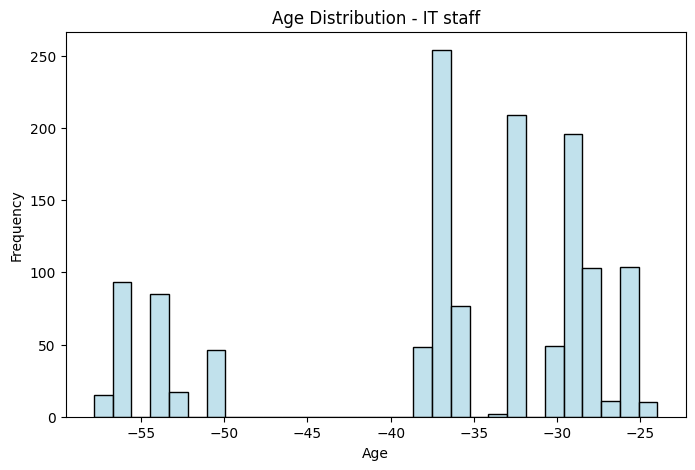

In [35]:
# Calculate age from DAYS_BIRTH
merged_data['Age'] = (-merged_data['DAYS_BIRTH']) / 365.25

# Unique occupation types
occupation_types = merged_data['OCCUPATION_TYPE'].dropna().unique()

# Plot age distribution for each occupation type
for occupation in occupation_types:
    plt.figure(figsize=(8, 5))
    subset = merged_data[merged_data['OCCUPATION_TYPE'] == occupation]
    sns.histplot(data=subset, x='Age', bins=30, color='lightblue', kde=False)
    plt.title(f'Age Distribution - {occupation}')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.show()


/tmp/ipykernel_14220/2674639871.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x_label, y='Proportion_Past_Due', palette='viridis')


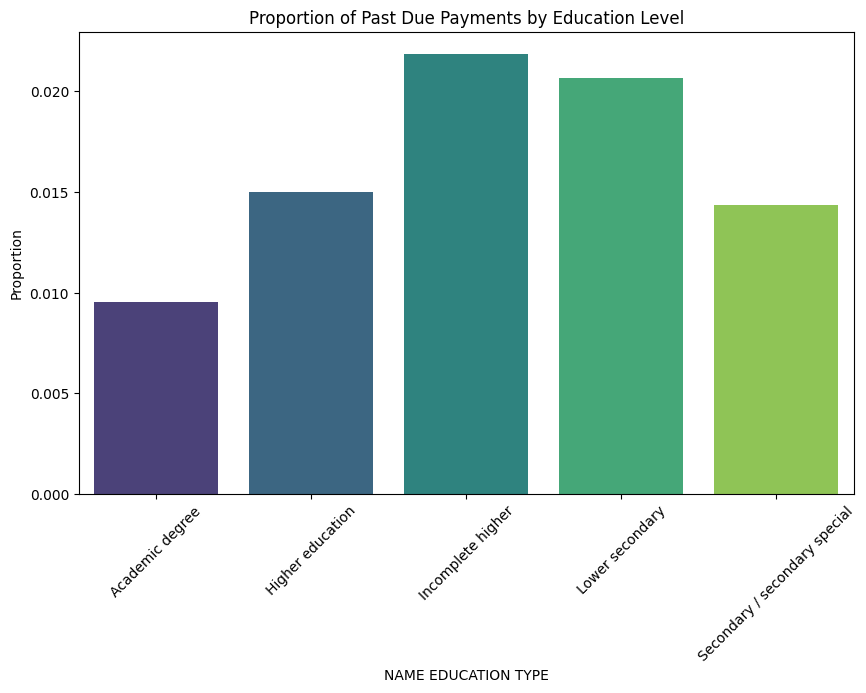

/tmp/ipykernel_14220/2674639871.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x_label, y='Proportion_Past_Due', palette='viridis')


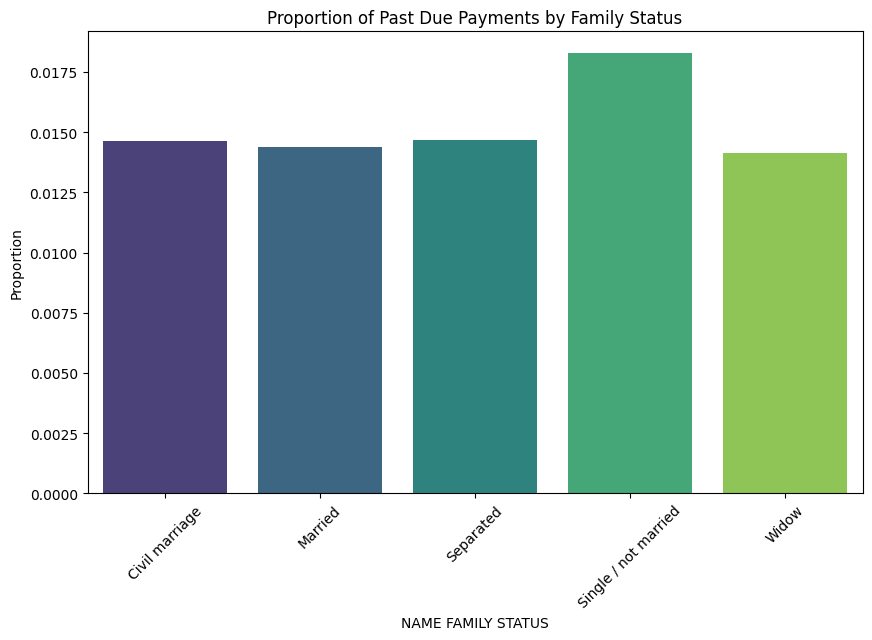

/tmp/ipykernel_14220/2674639871.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x_label, y='Proportion_Past_Due', palette='viridis')


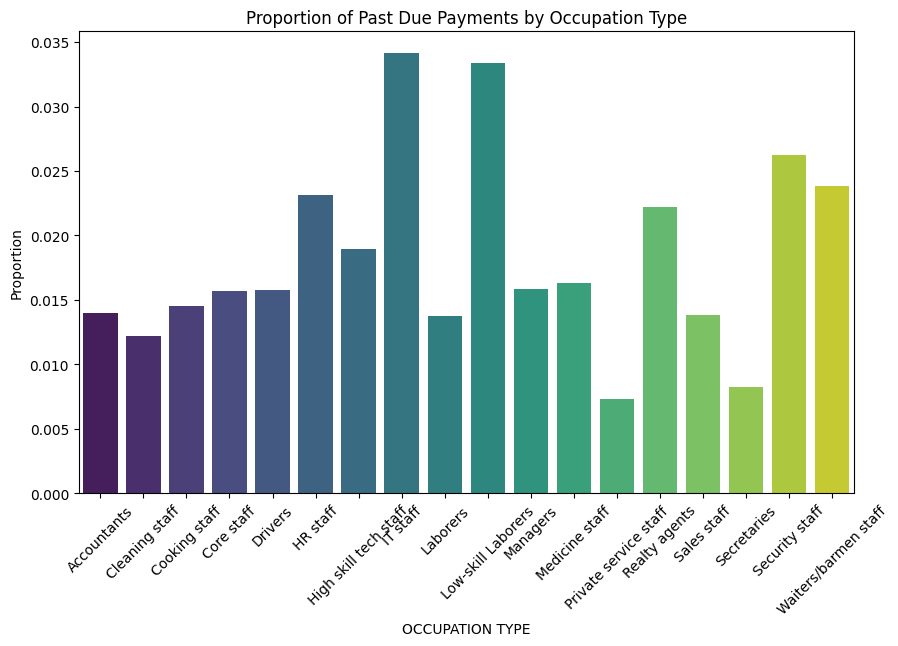

In [36]:
# Summarize proportions
education_summary = merged_data.groupby('NAME_EDUCATION_TYPE')['STATUS'].apply(lambda x: (x == 1).mean()).reset_index(name='Proportion_Past_Due')
family_status_summary = merged_data.groupby('NAME_FAMILY_STATUS')['STATUS'].apply(lambda x: (x == 1).mean()).reset_index(name='Proportion_Past_Due')
occupation_summary = merged_data.groupby('OCCUPATION_TYPE')['STATUS'].apply(lambda x: (x == 1).mean()).reset_index(name='Proportion_Past_Due')

# Plot bar charts
for data, title, x_label in zip(
    [education_summary, family_status_summary, occupation_summary],
    ['Proportion of Past Due Payments by Education Level',
     'Proportion of Past Due Payments by Family Status',
     'Proportion of Past Due Payments by Occupation Type'],
    ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE']
):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=x_label, y='Proportion_Past_Due', palette='viridis')
    plt.title(title)
    plt.xlabel(x_label.replace('_', ' '))
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.show()


## Encoding the categories and prepping features

Turning the text columns into numbers, looking at the correlations, and dropping the columns that won't pull their weight in a model (IDs, the constant phone flags).

In [37]:
# Convert categorical columns to numeric using pandas' factorization
columns_to_convert = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE','Ownership_Status'
]

for column in columns_to_convert:
    if column in merged_data.columns:  # Check if column exists in the dataset
        merged_data[column] = pd.factorize(merged_data[column])[0]

# Check the updated dataset
merged_data.head()
merged_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  int64  
 2   FLAG_OWN_CAR         777715 non-null  int64  
 3   FLAG_OWN_REALTY      777715 non-null  int64  
 4   CNT_CHILDREN         777715 non-null  float64
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  int64  
 7   NAME_EDUCATION_TYPE  777715 non-null  int64  
 8   NAME_FAMILY_STATUS   777715 non-null  int64  
 9   NAME_HOUSING_TYPE    777715 non-null  int64  
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  float64
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL       

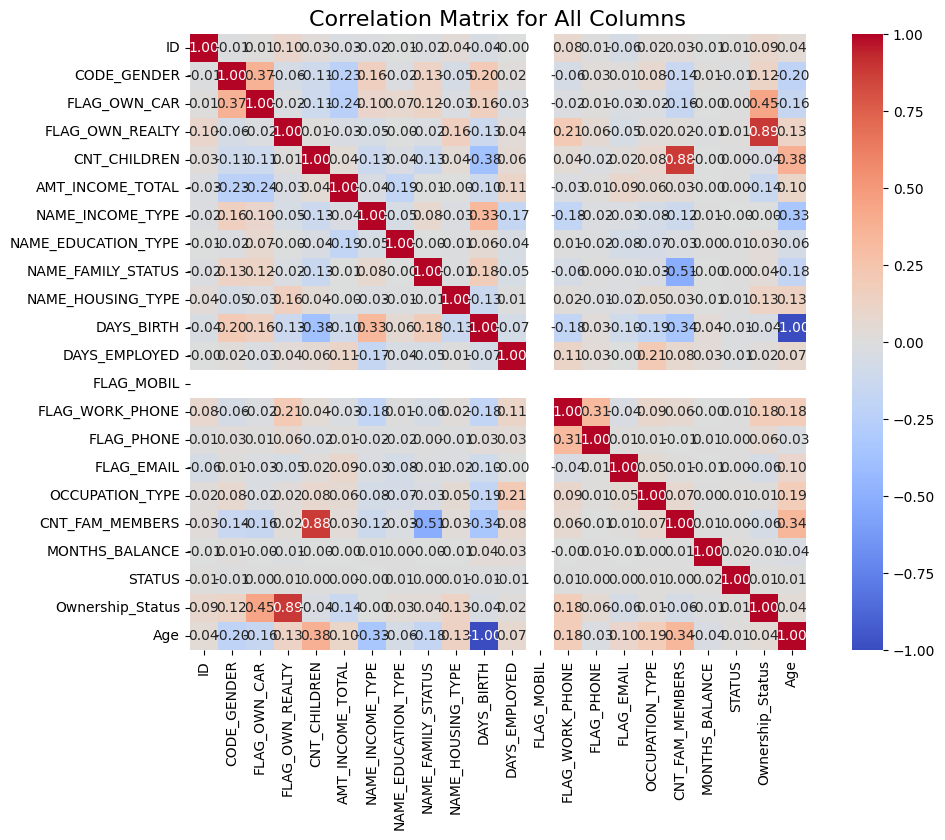

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = merged_data.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)

# Add title
plt.title('Correlation Matrix for All Columns', fontsize=16)

# Show the plot
plt.show()


In [39]:
# Drop the useless columns from the dataset
merged_data = merged_data.drop(columns=['ID', 'FLAG_PHONE', 'FLAG_MOBIL'], errors='ignore')

# Check the updated dataset
merged_data.head()


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,Ownership_Status,Age
0,0,0,0,0.0,380250.0,0,0,0,0,12005,4542.0,1,0,0,2.0,0,0,0,-32.867899
1,0,0,0,0.0,380250.0,0,0,0,0,12005,4542.0,1,0,0,2.0,1,0,0,-32.867899
2,0,0,0,0.0,380250.0,0,0,0,0,12005,4542.0,1,0,0,2.0,2,0,0,-32.867899
3,0,0,0,0.0,380250.0,0,0,0,0,12005,4542.0,1,0,0,2.0,3,0,0,-32.867899
4,0,0,0,0.0,380250.0,0,0,0,0,12005,4542.0,1,0,0,2.0,4,0,0,-32.867899


In [40]:
merged_data['STATUS'] = status_col

## Balancing the classes and modelling

The target is pretty imbalanced, so I oversample the minority class and scale the features first, then train the three models and compare them on the same metrics.

In [41]:
# the classes in STATUS are imbalanced. instead of oversampling, we handle the
# imbalance inside the models with class weights (see the model cells below),
# so here we only split and scale.
X = merged_data.drop(columns=['STATUS'])   # Features
y = merged_data['STATUS']                  # Target variable

# 1) split first, on the raw data. stratify keeps the same class ratio in both sets.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# 2) scaling: fit on the training data only, then apply that same scaling to the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# keep them as DataFrames so the column names stick around
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train_raw.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test_raw.index)

# no oversampling: the data keeps its real class ratio in both train and test
print("training set class balance:")
print(y_train.value_counts())
print("\ntest set class balance:")
print(y_test.value_counts())

training set class balance:
STATUS
no past dues    536298
past dues         8102
Name: count, dtype: int64

test set class balance:
STATUS
no past dues    229842
past dues         3473
Name: count, dtype: int64


Accuracy: 0.56
Confusion Matrix:
[[129649 100193]
 [  1566   1907]]
Precision: 0.02
Recall: 0.55
F1 Score: 0.04


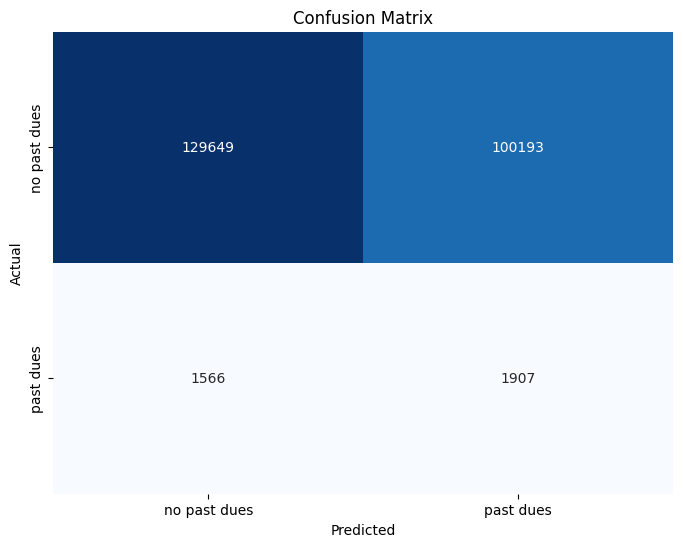

In [42]:
# Logistic regression. class_weight='balanced' makes the rare 'past dues' class
# count more during training, instead of duplicating its rows.
logit_model = LogisticRegression(max_iter=1000, random_state=123, class_weight='balanced')
logit_model.fit(X_train_scaled, y_train)

# predict on the test set
y_pred_probs = logit_model.predict_proba(X_test_scaled)[:, 1]  # P(positive class)
y_pred_classes = (y_pred_probs > 0.5).astype(int)
y_pred_labels = np.where(y_pred_classes == 1, "past dues", "no past dues")

# accuracy
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"Accuracy: {accuracy:.2f}")

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_labels, labels=["no past dues", "past dues"])
print("Confusion Matrix:")
print(conf_matrix)

# precision / recall / f1 for the past-due class
precision = precision_score(y_test, y_pred_labels, pos_label="past dues")
recall = recall_score(y_test, y_pred_labels, pos_label="past dues")
f1 = f1_score(y_test, y_pred_labels, pos_label="past dues")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# plot confusion matrix
conf_matrix_df = pd.DataFrame(conf_matrix,
                              index=["no past dues", "past dues"],
                              columns=["no past dues", "past dues"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix:
 [[222219   7623]
 [  1703   1770]]
Accuracy: 0.96
Precision: 0.19
Recall: 0.51
F1 Score: 0.28


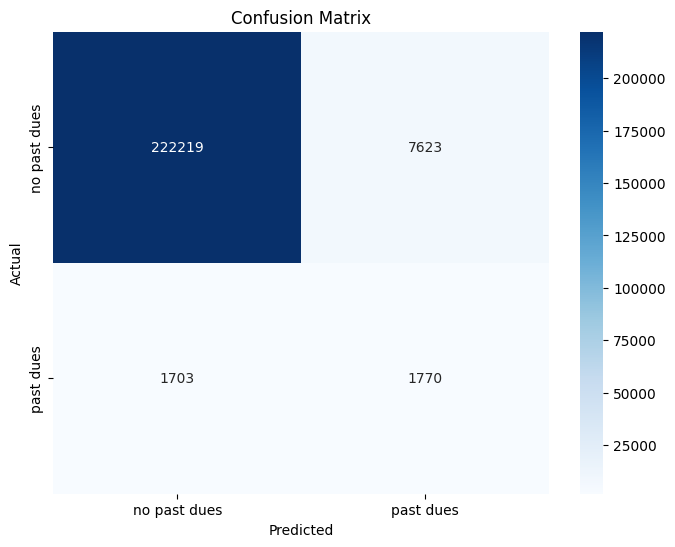

In [43]:
# Random Forest, same idea: class_weight='balanced' handles the imbalance
rf_model = RandomForestClassifier(
    n_estimators=500,    # Number of trees
    max_features=10,     # Number of features to consider at each split
    min_samples_leaf=5,  # Minimum samples per leaf node
    random_state=300,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)

# predict on the test set
y_pred = rf_model.predict(X_test_scaled)

# metrics
conf_matrix = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='past dues', average='binary')
recall = recall_score(y_test, y_pred, pos_label='past dues', average='binary')
f1 = f1_score(y_test, y_pred, pos_label='past dues', average='binary')

print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.92
Precision: 0.13
Recall: 0.69
F1 Score: 0.21


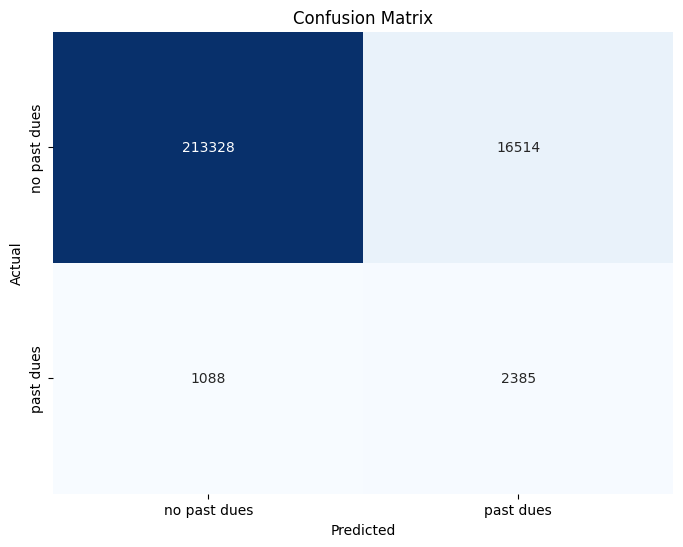

In [44]:
# XGBoost needs numeric labels, so map the target to 0/1 (past dues = 1)
y_train_bin = (y_train == 'past dues').astype(int)
y_test_bin  = (y_test == 'past dues').astype(int)

# XGBoost has no class_weight; the equivalent for imbalance is scale_pos_weight,
# set to the ratio of negatives to positives in the training set.
scale_pos_weight = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=4000,
    learning_rate=0.01,
    max_depth=10,
    min_child_weight=5,
    subsample=0.6,
    colsample_bytree=0.6,
    gamma=0.5,
    reg_lambda=1,
    reg_alpha=0.01,
    random_state=500,
    scale_pos_weight=scale_pos_weight
)
xgb_model.fit(X_train_scaled, y_train_bin)

# predict on the test set
y_pred_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_class = (y_pred_probs > 0.5).astype(int)

# metrics
conf_matrix = confusion_matrix(y_test_bin, y_pred_class)
accuracy = accuracy_score(y_test_bin, y_pred_class)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test_bin, y_pred_class)
recall = recall_score(y_test_bin, y_pred_class)
f1 = f1_score(y_test_bin, y_pred_class)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# plot confusion matrix
conf_matrix_df = pd.DataFrame(conf_matrix,
                              index=['no past dues', 'past dues'],
                              columns=['no past dues', 'past dues'])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression: ROC-AUC = 0.574,  PR-AUC (avg precision) = 0.020
Random Forest: ROC-AUC = 0.895,  PR-AUC (avg precision) = 0.265
XGBoost: ROC-AUC = 0.886,  PR-AUC (avg precision) = 0.271


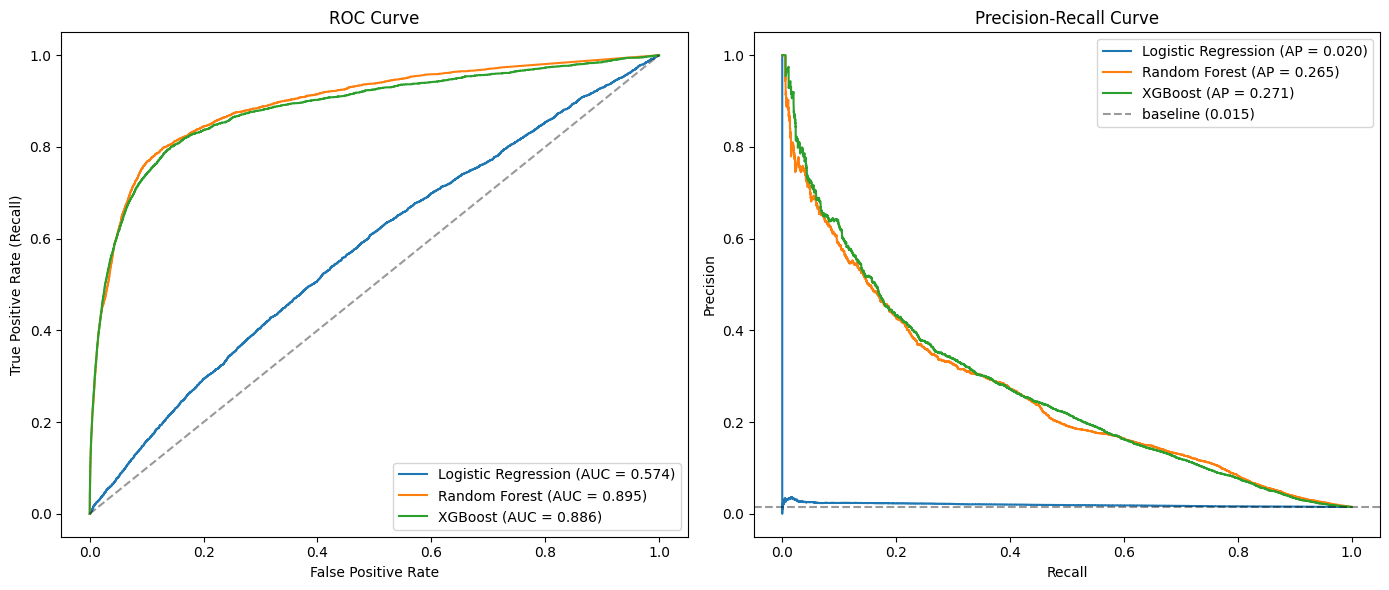

In [45]:
# ROC and PR curves + AUC for all three models
# (run this AFTER the logistic regression, random forest and XGBoost cells)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# true test labels as 0/1 (past dues = 1)
y_true = (y_test == 'past dues').astype(int)

# each fitted model with the label that counts as "positive"
models = {
    'Logistic Regression': (logit_model, 'past dues'),
    'Random Forest':       (rf_model, 'past dues'),
    'XGBoost':             (xgb_model, 1),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, (model, pos_label) in models.items():
    # probability of the positive class
    pos_idx = list(model.classes_).index(pos_label)
    probs = model.predict_proba(X_test_scaled)[:, pos_idx]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_true, probs)
    ap = average_precision_score(y_true, probs)
    ax2.plot(rec, prec, label=f"{name} (AP = {ap:.3f})")

    print(f"{name}: ROC-AUC = {roc_auc:.3f},  PR-AUC (avg precision) = {ap:.3f}")

# ROC: dashed diagonal = a model with no skill
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.set_title("ROC Curve")
ax1.legend(loc="lower right")

# PR: dashed line = baseline (the share of past-due clients)
baseline = y_true.mean()
ax2.axhline(baseline, color='k', ls='--', alpha=0.4, label=f"baseline ({baseline:.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()